In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Disease.csv")
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(246945, 378)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [5]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
disease_count = df["diseases"].value_counts()

disease_count.head(10)

diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
peripheral nerve disorder         1215
esophagitis                       1215
vaginal cyst                      1215
conjunctivitis due to allergy     1215
Name: count, dtype: int64

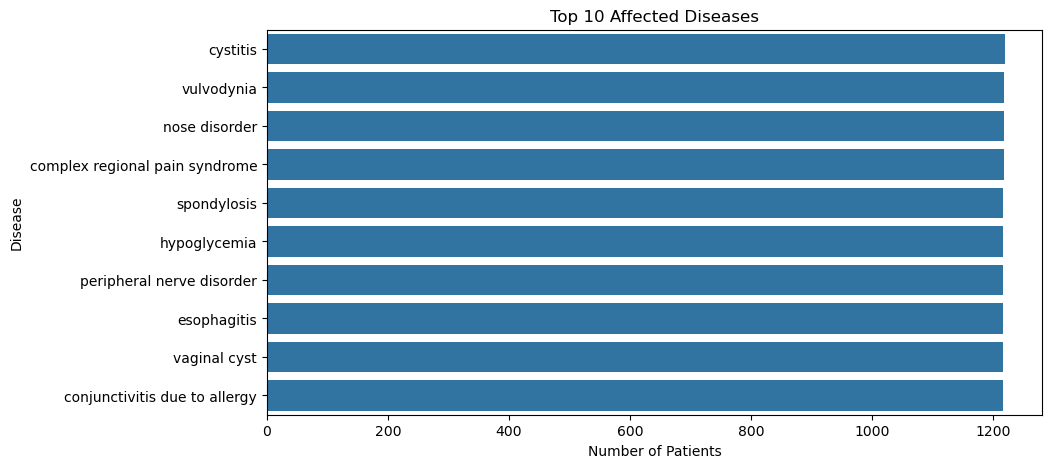

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=disease_count.head(10).values,
    y=disease_count.head(10).index
)

plt.title("Top 10 Affected Diseases")
plt.xlabel("Number of Patients")
plt.ylabel("Disease")

plt.show()

In [18]:
X = df.drop(
    "diseases",
    axis=1
)

y = df["diseases"]

In [19]:
df["diseases"].unique()

array(['panic disorder', 'vocal cord polyp', 'turner syndrome',
       'cryptorchidism', 'poisoning due to ethylene glycol',
       'atrophic vaginitis', 'fracture of the hand',
       'cellulitis or abscess of mouth', 'eye alignment disorder',
       'headache after lumbar puncture', 'pyloric stenosis',
       'salivary gland disorder', 'osteochondrosis', 'injury to the knee',
       'metabolic disorder', 'vaginitis', 'sick sinus syndrome',
       'tinnitus of unknown cause', 'glaucoma', 'eating disorder',
       'transient ischemic attack', 'pyelonephritis',
       'rotator cuff injury', 'chronic pain disorder',
       'problem during pregnancy', 'liver cancer', 'atelectasis',
       'injury to the hand', 'choledocholithiasis', 'injury to the hip',
       'cirrhosis', 'thoracic aortic aneurysm', 'subdural hemorrhage',
       'diabetic retinopathy', 'fibromyalgia', 'ischemia of the bowel',
       'fetal alcohol syndrome', 'peritonitis', 'injury to the abdomen',
       'acute pancreati

In [20]:
print(
    "Total Diseases:",
    df["diseases"].nunique()
)

Total Diseases: 773


In [21]:
df.isnull().sum().sum()

0

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)